# E-HLAstic: Model Development

In [ ]:
import os
from functools import reduce

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm, colors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

# Define useful functions for the analysis

np.random.seed(100)

# Configuration API
_config = {}

def configure(**kwargs):
    """Configure module-level parameters from `index.qmd` or other callers.

    Example: configure(project_dir=..., data_dir=..., fig_dir=...)
    """
    _config.update(kwargs)

def get_config(key, default=None):
    return _config.get(key, default)


def sig3(x):
    return format(x, ".3g")

# Function to encode peptides using a factor matrix
def encode_peptide(PeptideList, FactorMat):
    """
    Encodes a list of peptides into a numerical matrix representation using a given factor matrix.
    Each peptide is represented as a sequence of characters (e.g., amino acids), and each character is mapped to a row in the factor matrix.
    The encoded representation of each peptide is obtained by concatenating the factor vectors of its characters.
    Parameters
    ----------
    PeptideList : list of str
        List of peptides, where each peptide is a string of equal length.
    FactorMat : pandas.DataFrame
        DataFrame where rows correspond to possible peptide characters (e.g., amino acids) and columns correspond to numerical factors.
    Returns
    -------
    numpy.ndarray
        A 2D array of shape (number of peptides, peptide length * number of factors), where each row is the encoded representation of a peptide.
    Raises
    ------
    KeyError
        If a character in any peptide is not found in the index of FactorMat.
    """
    NumPeptides = len(PeptideList)    
    PepLen = len(PeptideList[0])    
    NumFactor = FactorMat.shape[1]    
    EncodedPeptideLen = PepLen * NumFactor    
    PeptideMatrix = np.zeros((NumPeptides, EncodedPeptideLen))
    for i,p in enumerate(PeptideList):    
        PeptideMatrix[i,] = np.concatenate([FactorMat.loc[j,] for j in p])    
    return PeptideMatrix


# probability mapping function: map ranks in [0.5, 1.0] to probabilities in [1.0, 0.0]
def rank_to_prob(rk, pw):
    rk = float(rk)
    if not np.isfinite(rk):
        raise ValueError(f"Rank must be finite, got {rk!r}")

    # Exact linear mapping on the valid interval, then clamp to a probability range.
    base_prob = np.clip(2.0 * (1.0 - rk), 0.0, 1.0)
    return float(np.power(base_prob, pw))


def gen_label_by_rank(rk, pw, rng):
    rk = float(rk)
    if not np.isfinite(rk):
        raise ValueError(f"Rank must be finite, got {rk!r}")

    if rk <= 0.5:
        return 1.0
    if rk >= 1.0:
        return 0.0

    p_1 = np.clip(rank_to_prob(rk, pw), 0.0, 1.0)
    return rng.choice([0.0, 1.0], size=1, p=[1.0 - p_1, p_1])[0]
        
# Function to display the weight matrix of the model coefficients for 9-mer sequences
def show_weight_matrix(Coef_9mers, Scheme, Path):
    """
    Displays a heatmap visualization of model coefficient weights for 9-mer sequences.
    Parameters:
        Coef_9mers (array-like): A 2D array of shape (9, 24) representing the model coefficients
            for each position (1-9) and each amino acid (24 standard and special amino acids).
        Scheme (str): A string indicating the name or description of the coefficient scheme,
            used as the plot title.
    The function creates a matplotlib figure showing the coefficient matrix as a color-coded heatmap,
    with amino acids on the x-axis and sequence positions on the y-axis. The color scale is centered,
    and a colorbar is included for reference.
    """
    plt.figure(figsize = (20, 12))
    plt.rcParams.update({'font.size': 24})
    cmap = cm.coolwarm
    plt.imshow(Coef_9mers[:20, :], norm=colors.CenteredNorm(), cmap=cmap)
    plt.title(f"Model Coefficients for {Scheme}")
    plt.xticks(ticks = range(20), labels = ["A","R","N","D","C",
                                            "Q","E","G","H","I",
                                            "L","K","M","F","P",
                                            "S","T","W","Y","V"])
    plt.xlabel("Amino-Acid")
    plt.yticks(ticks = range(9), labels = [1,2,3,4,5,6,7,8,9])
    plt.ylabel("Position")
    plt.colorbar(fraction=0.02, pad=0.04)
    plt.tight_layout()
    # ensure output directory exists before saving
    dirpath = os.path.dirname(Path)
    if dirpath:
        os.makedirs(dirpath, exist_ok=True)
    base_path, _ = os.path.splitext(Path)
    plt.savefig(base_path + '.pdf', dpi=600)
    plt.savefig(base_path + '.png', dpi=600)
    plt.show()


In [ ]:
"""Run the analysis. Requires `configure(data_dir=..., fig_dir=...)` to be
called before running when used from notebooks/Quarto.
"""
PepLen = 9

# Change this to the root directory of the project on your local machine. For example, if the project is located at "C:/Users/YourUsername/Downloads/Code_for_Submission", set project_dir to that path.
project_dir = 'D:/Projects/ehlastic_release' 

data_dir = os.path.join(project_dir, 'data') #get_config('data_dir')
fig_dir = os.path.join(project_dir, 'figure', 'Fig_Model') #get_config('fig_dir')


if data_dir is None or fig_dir is None:
    raise RuntimeError('Please call configure(data_dir=..., fig_dir=...) before run()')

# Load data
IEDB = pd.read_csv(os.path.join(data_dir, "IEDB", "epitope_table_export_1675070195.csv"), skiprows = [0])

IEDB_NetMHCpan = pd.read_csv(os.path.join(data_dir, "IEDB", "IEDB_HLA_E_9mer_netMHCpan.csv"))

IEDB_NetMHCpan_DF = IEDB_NetMHCpan.merge(IEDB, left_on = "Peptide", right_on = "Description", how = "inner")
IEDB_NetMHCpan_DF['Length'] = IEDB_NetMHCpan_DF['Peptide'].apply(len)

IEDB_9mers_NetMHCpan_DF = IEDB_NetMHCpan_DF.loc[IEDB_NetMHCpan_DF.Length == PepLen, ["Peptide", "Rank_EL_HLA-E*0103", "Length", "Epitope IRI"]]

IEDB_9mers_NetMHCpan_DF['Label'] = IEDB_9mers_NetMHCpan_DF['Rank_EL_HLA-E*0103'].apply(lambda x: 1 if x < 0.5 else 0)


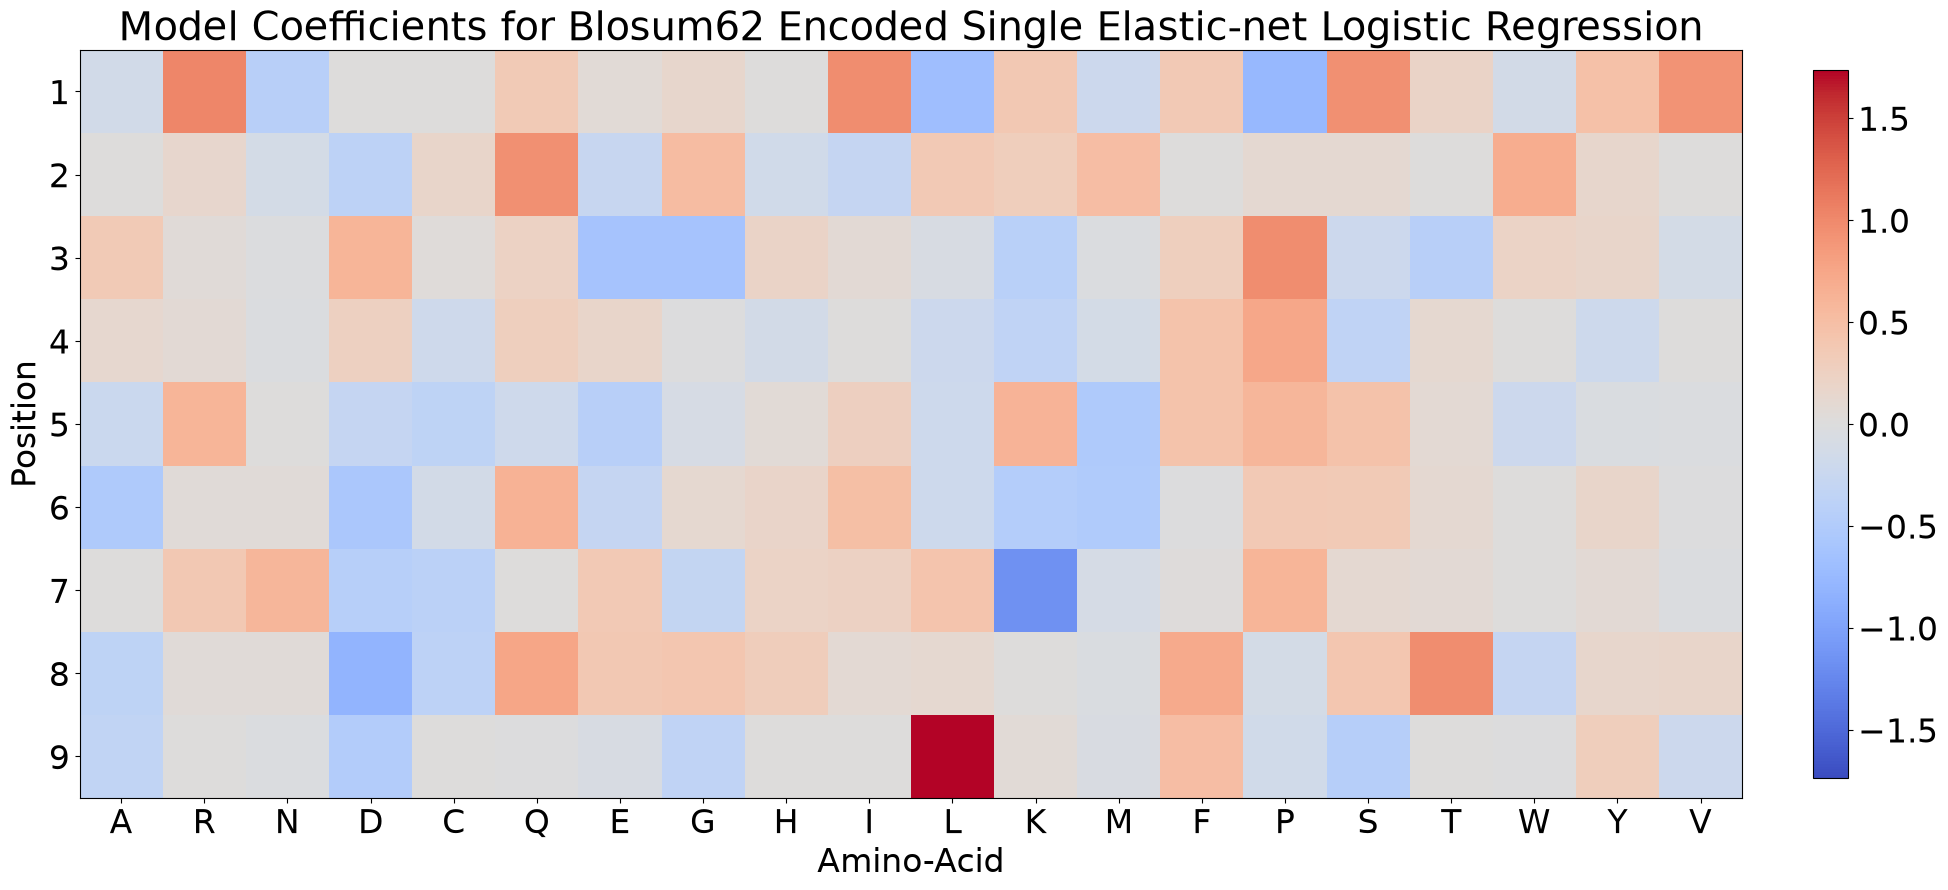

In [ ]:

num_iedb_9mers = IEDB_9mers_NetMHCpan_DF.shape[0]

num_iedb_positive_9mers = IEDB_9mers_NetMHCpan_DF[IEDB_9mers_NetMHCpan_DF.Label == 1].shape[0]

# Construct Blosum62 Encoded Peptide Matrix
Blosum62 = pd.read_csv(os.path.join(data_dir, "ProteinAlignment-GapPenaltyTraceback-BLOSUM62Matrix", "BLOSUM62.txt"))
Blosum62.set_index("amino.acid", inplace=True)

IEDB_9mers_Blosum62_Matrix = encode_peptide(IEDB_9mers_NetMHCpan_DF.Peptide, Blosum62)

# Encoding HLA-E binding 9mers with Blosom 62 Encoding:
regr = LogisticRegression(random_state=0, solver = 'saga', penalty = 'elasticnet', l1_ratio = .2, max_iter = 10000)

regr.fit(IEDB_9mers_Blosum62_Matrix, IEDB_9mers_NetMHCpan_DF.Label)

Coef_9mers = np.reshape(regr.coef_, newshape = (PepLen, 24) )[:, :20]

show_weight_matrix(Coef_9mers, 'Blosum62 Encoded Single Elastic-net Logistic Regression', os.path.join(fig_dir, 'Baseline_Logistic'))

# Max' Validated HLA-E Binding Peptide
Max_DF = pd.read_excel(os.path.join(data_dir, "Max_Gerry", "Max_Tested_Peptides_CellReports.xlsx"), sheet_name="Max_Original")
Max_DF = Max_DF.rename(columns={'HLA-E Bound': 'Label'})

Max_9mers_DF = Max_DF.loc[Max_DF['Sequence'].apply(len) == PepLen, ['Sequence', 'Label', 'NetMHCpan_EL_Rank', 'MHCFlurry2_presentation_percentile']]

Max_9mers_DF = Max_9mers_DF[~Max_9mers_DF['Sequence'].isin(IEDB_9mers_NetMHCpan_DF['Peptide'])]

Max_9mers_Blosum62_Matrix = encode_peptide(Max_9mers_DF.Sequence, Blosum62)

Max_9mers_Pred_Prob = regr.predict_proba(Max_9mers_Blosum62_Matrix)

Max_9mers_DF['Baseline_Model'] = Max_9mers_Pred_Prob[:, 1]

num_max_9mers = len(Max_9mers_DF.Sequence.unique())

num_max_positive_9mers = np.sum(Max_9mers_DF.Label)

# Ensemble Elastic-net Logistic Regression Model
seed = 678578

rng = np.random.default_rng(seed)

sub_seed = 1234

rng_submodels = np.random.default_rng(sub_seed)

Train_Ratio = .4

Num_Sub_Models = 20

replace = False

r_submodels = rng.random(Num_Sub_Models) * .8 + .1 # r for elastic net regression range (.1, .9)


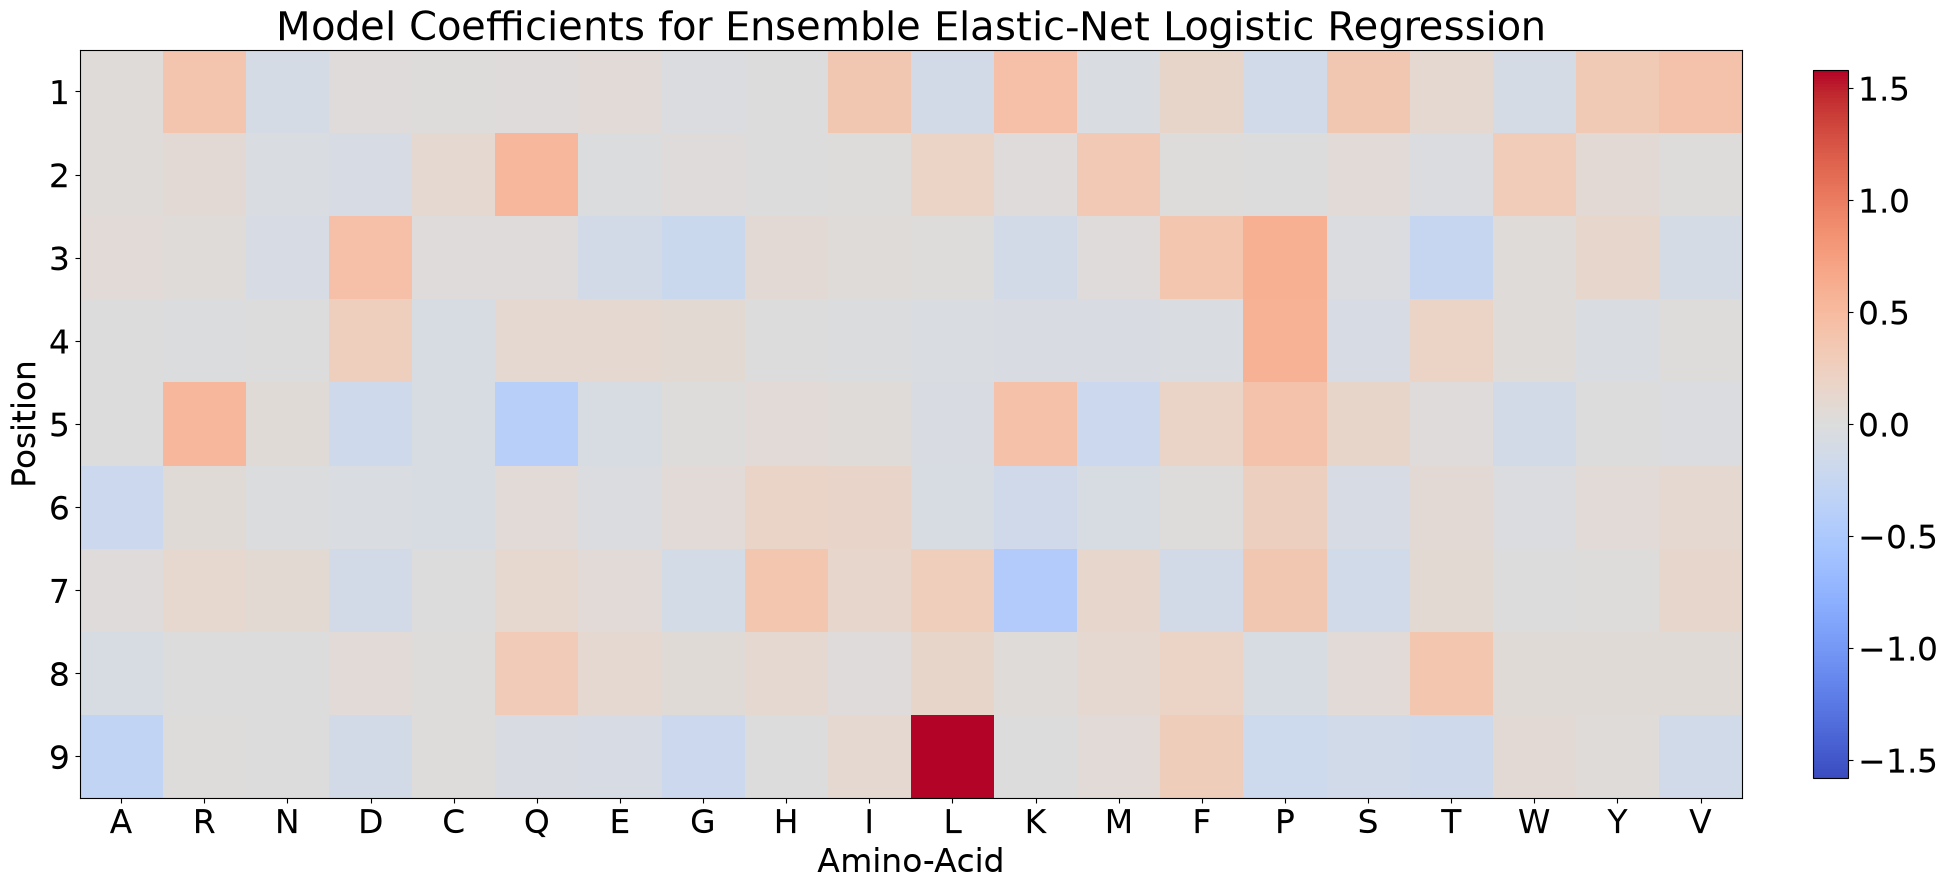

In [ ]:

IEDB_Label = [IEDB_9mers_NetMHCpan_DF["Rank_EL_HLA-E*0103"].apply(lambda rk: gen_label_by_rank(rk, 3, rng_submodels)).to_numpy() for j in np.arange(Num_Sub_Models)]

IEDB_9mers_Blosum62_with_Label_Matrix_List = [np.hstack([IEDB_9mers_Blosum62_Matrix, IEDB_Label[j][:,None]]) for j in np.arange(Num_Sub_Models)]

Ensemble_Averaging_Selected_Training_Mat = [None] * Num_Sub_Models

for j,M in enumerate(IEDB_9mers_Blosum62_with_Label_Matrix_List):
    
    rng_submodels.shuffle(M)

    Num_Training_Rows = M.shape[0]

    Num_Sampled_Rows = int(Num_Training_Rows * Train_Ratio)

    if replace == False:

        Ensemble_Averaging_Selected_Training_Mat[j] = rng_submodels.choice(M, size = Num_Sampled_Rows, replace = False) 

    else:
    
        Ensemble_Averaging_Selected_Training_Mat[j] = rng_submodels.choice(Ensemble_Averaging_Selected_Training_Mat[j], size = M.shape[0], replace = True)

Ensemble_Averaging_Train_Matrix = [Ensemble_Averaging_Selected_Training_Mat[j][:, 0:-1] for j in np.arange(Num_Sub_Models)]    

Ensemble_Averaging_Train_Label = [Ensemble_Averaging_Selected_Training_Mat[j][:, -1] for j in np.arange(Num_Sub_Models)]

Ensemble_Model = [LogisticRegression(random_state=0, solver = 'saga', penalty = 'elasticnet', l1_ratio = k, max_iter = 10000) for k in r_submodels]

Ensemble_Model_Fit = [Ensemble_Model[k].fit(Ensemble_Averaging_Train_Matrix[k], Ensemble_Averaging_Train_Label[k]) for k in np.arange(Num_Sub_Models)]

Ensemble_Averaging_Coef = [np.reshape(Ensemble_Model_Fit[k].coef_, newshape = (9, 24) ) for k in np.arange(Num_Sub_Models)]

Ensemble_Averaging_L1_Mean_Coef = np.mean([Ensemble_Averaging_Coef[k][:, :20] for k in np.arange(Num_Sub_Models)], axis = 0)

EHLAstic_Pred_Prob = [Ensemble_Model_Fit[k].predict_proba(Max_9mers_Blosum62_Matrix)[:, 1] for k in np.arange(Num_Sub_Models)]

EHLAstic_Mean_Pred_Prob = reduce(lambda x, y: x+y, EHLAstic_Pred_Prob)

EHLAstic_Mean_Pred_Prob = EHLAstic_Mean_Pred_Prob / Num_Sub_Models

Max_9mers_DF['EHLAstic_Pred_Prob'] = EHLAstic_Mean_Pred_Prob

show_weight_matrix(Ensemble_Averaging_L1_Mean_Coef, "Ensemble Elastic-Net Logistic Regression", os.path.join(fig_dir, 'Ensemble_ElasticNet'))

average_precision_netmhcpan = average_precision_score(Max_9mers_DF.Label, 1 - Max_9mers_DF.NetMHCpan_EL_Rank/100.)
average_precision_mhcflurry = average_precision_score(Max_9mers_DF.Label, 1 - Max_9mers_DF.MHCFlurry2_presentation_percentile / 100.)
average_precision_logistic = average_precision_score(Max_9mers_DF.Label, Max_9mers_DF.Baseline_Model) 
average_precision_ehlastic = average_precision_score(Max_9mers_DF.Label, EHLAstic_Mean_Pred_Prob)


In [ ]:
average_precision_netmhcpan

0.9950827468058271

In [ ]:
average_precision_mhcflurry

0.9742674968127618

In [ ]:
average_precision_logistic

0.9926923093513353

In [ ]:
average_precision_ehlastic

0.9972283057117972